# event 

In [1]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

In [2]:
GAS_PRICE_GWEI = 0.515        # gas price
ETH_PRICE_USD = 2207.35       # ETH价格
WORK_XLSX = "files/work_dataset.xlsx"
HEX_XLSX = "files/hex.xlsx"
SAMPLE_MEDIAN = "files/event-2604.09731v1.csv"
SAMPLE_MAXIMUM = "files/event-2603.25100v1.csv"

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

In [3]:
def gas_to_usd(gas):
    if pd.isna(gas):
        return 0
    eth = int(gas) * GAS_PRICE_GWEI * 1e-9
    return eth * ETH_PRICE_USD

def wei_to_usd(wei):
    eth = int(wei) * 1e-18
    return eth * ETH_PRICE_USD

def size_to_gas(size):
    return 40.39 * size + 12958.30

In [4]:
def get_df():
    df = pd.read_excel(WORK_XLSX)
    return df[(df["id"]=="2604.09731v1") | (df["id"]=="2603.25100v1")]
get_df()

,id,title,authors,file_path,tar_size,tex_size_clean
23,2604.09731v1,SMART: When is it Actually Worth Expanding a S...,"['Lifu Wang', 'Pan Zhou']",files/downloads/2604.09731v1.SMART__When_is_it...,960866,83581
173,2603.25100v1,From Logic Monopoly to Social Contract: Separa...,['Anbang Ruan'],files/downloads/2603.25100v1.From_Logic_Monopo...,3578011,691333


In [5]:
median = pd.read_csv(SAMPLE_MEDIAN)

In [6]:
maximum = pd.read_csv(SAMPLE_MAXIMUM)

In [7]:
def draw_pipeline_csv(df, run_id=0):
    df = df[df["run"] == run_id]

    # =========================
    # 🎨 颜色
    # =========================
    colors = {
        "tex": "#4CAF50",
        "asset": "#2196F3",
        "contract": "#FF9800",
        "read": "#9C27B0",
    }

    # =========================
    # 🔢 分组
    # =========================
    tex_ids = sorted(df[df["stage"] == "tex_upload"]["id"].unique())
    asset_ids = sorted(df[df["stage"] == "asset_upload"]["id"].unique())

    fig_height = 0.2 * (len(tex_ids) + len(asset_ids) + 3)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    y_pos = 0
    y_ticks = []
    y_labels = []

    upload_end_all = []
    read_end_all = []

    bar_height = 0.7

    # =========================
    # 🟧 CONTRACT（1行）
    # =========================
    y_ticks.append(y_pos)
    y_labels.append("Contract")

    for _, row in df[df["stage"].isin(["submit", "read_contract"])].iterrows():
        start, end = row["start"], row["end"]

        color = colors["contract"] if row["stage"] == "submit" else colors["read"]
        alpha = 1.0 if row["stage"] == "submit" else 0.4

        ax.barh(y_pos, end - start, bar_height, left=start, color=color, alpha=alpha)

        # USD
        usd = gas_to_usd(row.get("gas"))
        if usd:
            ax.text((start + end)/2, y_pos, f"${usd:.2f}", ha="center", va="center", fontsize=8)

        if row["stage"] == "submit":
            upload_end_all.append(end)
        else:
            read_end_all.append(end)

    y_pos += 1

    # =========================
    # 📗 TEX（多行）
    # =========================
    for tex_id in tex_ids:
        y_ticks.append(y_pos)
        y_labels.append("Tex")

        upload = df[(df["stage"] == "tex_upload") & (df["id"] == tex_id)]
        rec = df[(df["stage"] == "reconstruct_tex") & (df["id"] == tex_id)]

        if not upload.empty:
            row = upload.iloc[0]
            start, end = row["start"], row["end"]

            ax.barh(y_pos, end - start, bar_height, left=start, color=colors["tex"])

            usd = gas_to_usd(row.get("gas"))
            if usd:
                ax.text((start + end)/2, y_pos, f"${usd:.2f}", ha="center", va="center", fontsize=8)

            upload_end_all.append(end)

        if not rec.empty:
            row = rec.iloc[0]
            start, end = row["start"], row["end"]

            ax.barh(y_pos, end - start, bar_height, left=start, color=colors["tex"], alpha=0.4)

            read_end_all.append(end)

        y_pos += 1

    # =========================
    # 📘 ASSET（多行）
    # =========================
    for asset_id in asset_ids:
        y_ticks.append(y_pos)
        y_labels.append("Asset")

        upload = df[(df["stage"] == "asset_upload") & (df["id"] == asset_id)]
        down = df[(df["stage"] == "asset_download") & (df["id"] == asset_id)]

        if not upload.empty:
            row = upload.iloc[0]
            start, end = row["start"], row["end"]

            ax.barh(y_pos, end - start, bar_height, left=start, color=colors["asset"])

            usd = wei_to_usd(row.get("wei"))
            if usd:
                ax.text((start + end)/2, y_pos, f"${usd:.2f}", ha="center", va="center", fontsize=8)

            upload_end_all.append(end)

        if not down.empty:
            row = down.iloc[0]
            start, end = row["start"], row["end"]

            ax.barh(y_pos, end - start, bar_height, left=start, color=colors["asset"], alpha=0.4)

            read_end_all.append(end)

        y_pos += 1

    # =========================
    # 📏 分界线
    # =========================
    upload_end = max(upload_end_all)
    read_end = max(read_end_all)

    line1 = ax.axvline(upload_end, linestyle=":", color="red",
                       label=f"Publishing: {upload_end:.0f} ms")

    line2 = ax.axvline(read_end, linestyle=":", color="blue",
                       label=f"Reconstruction: {read_end - upload_end:.0f} ms")

    # =========================
    # 🧾 坐标
    # =========================
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

    ax.set_xlabel("Time (ms)")

    # =========================
    # 🧩 Legend
    # =========================
    legend_elements = [
        Patch(facecolor=colors["tex"], label="Tex Inscription"),
        Patch(facecolor=colors["tex"], alpha=0.4, label="Tex Reconstruction"),
        Patch(facecolor=colors["asset"], label="Asset Upload"),
        Patch(facecolor=colors["asset"], alpha=0.4, label="Asset Download"),
        Patch(facecolor=colors["contract"], label="Contract Submission"),
        Patch(facecolor=colors["read"], label="Contract Retrieval"),
        line1,
        line2,
    ]
    ax.set_ylim(-0.5, len(y_labels) - 0.5)
    ax.legend(handles=legend_elements, loc="upper left")

    plt.show()

In [8]:
def generate_pipeline_table_latex(df, run_id):
    df = df[df["run"] == run_id]

    # =========================
    # CONTRACT
    # =========================
    submit = df[df["stage"] == "submit"].iloc[0]
    read = df[df["stage"] == "read_contract"].iloc[0]

    contract_size = int(submit.get("size", 0))
    contract_usd = gas_to_usd(submit.get("gas"))
    submit_time = int(submit["end"] - submit["start"])
    read_time = int(read["end"] - read["start"])

    contract_row = f"\\textbf{{contract}} & {contract_size} && {contract_usd:.2f} & {submit_time:,} & {read_time:,} \\\\"

    # =========================
    # TEX
    # =========================
    tex_upload = df[df["stage"] == "tex_upload"]
    tex_rec = df[df["stage"] == "reconstruct_tex"]

    tex_size = int(tex_upload["size"].sum())
    tex_usd = tex_upload["gas"].apply(gas_to_usd).sum()
    tex_submit_time = int(tex_upload["end"].max() - tex_upload["start"].min())
    tex_read_time = int(tex_rec["end"].max() - tex_rec["start"].min())

    tex_row = f"\\textbf{{tex}} & {tex_size:,} && {tex_usd:.2f} & {tex_submit_time:,} & {tex_read_time:,} \\\\"

    # =========================
    # ASSETS
    # =========================
    assets = df[df["stage"] == "asset_upload"]

    asset_rows = []
    for _, row in assets.iterrows():
        file_id = row["id"]

        download = df[(df["stage"] == "asset_download") & (df["id"] == file_id)]

        read_time = 0
        if not download.empty:
            d = download.iloc[0]
            read_time = int(d["end"] - d["start"])

        size = int(row["size"])
        chunks = int(row["chunks"])
        usd = wei_to_usd(row["wei"])
        submit_time = int(row["end"] - row["start"])

        asset_rows.append(
            f"& {size:,} & {chunks} & {usd:.2f} & {submit_time:,} & {read_time:,} \\\\"
        )

    asset_block = ""
    if asset_rows:
        asset_block += f"\\multirow{{{len(asset_rows)}}}{{*}}{{\\textbf{{asset}}}} {asset_rows[0]}"
        for r in asset_rows[1:]:
            asset_block += f"\n    {r}"

    # =========================
    # FINAL TABLE
    # =========================
    latex = f"""
  \\begin{{tabular*}}{{\\columnwidth}}{{@{{\\extracolsep{{\\fill}}}}crrrrr}}
    \\toprule
    & \\multirow{{2}}{{*}}{{\\textbf{{Size}}(bytes)}} &\\multicolumn{{2}}{{c}}{{\\textbf{{Cost}}}} & \\multicolumn{{2}}{{c}}{{\\textbf{{Time}} (ms)}} \\\\
    &  &chunks & USD & submit & read \\\\
    \\midrule
    {contract_row}
    \\midrule
    {tex_row}
    \\midrule
    {asset_block}
    \\bottomrule
  \\end{{tabular*}}
""".strip()
    return latex


In [9]:
def compute_run_metrics(df):

    results = []

    for run_id, g in df.groupby("run"):

        start_global = g["start"].min()
        end_global = g["end"].max()

        total_time = end_global - start_global

        # =========================
        # TEX（串行）
        # =========================
        tex_g = g[g["stage"] == "tex_upload"]
        tex_time = tex_g["end"].max() - tex_g["start"].min() if not tex_g.empty else 0

        # =========================
        # ASSET（并行 → makespan）
        # =========================
        asset_g = g[g["stage"] == "asset_upload"]
        asset_time = (
            asset_g["end"].max() - asset_g["start"].min()
            if not asset_g.empty else 0
        )

        # =========================
        # CONTRACT（串行）
        # =========================
        submit = g[g["stage"] == "submit"]
        submit_time = submit["end"].values[0] - submit["start"].values[0] if not submit.empty else 0

        read = g[g["stage"] == "read_contract"]
        read_time = read["end"].values[0] - read["start"].values[0] if not read.empty else 0

        # =========================
        # RECONSTRUCT（并行）
        # =========================
        rec_g = g[g["stage"] == "reconstruct_tex"]
        reconstruct_time = (
            rec_g["end"].max() - rec_g["start"].min()
            if not rec_g.empty else 0
        )

        dl_g = g[g["stage"] == "asset_download"]
        download_time = (
            dl_g["end"].max() - dl_g["start"].min()
            if not dl_g.empty else 0
        )

        # =========================
        # 🔥 显式 critical path
        # =========================
        serial_path = tex_time + submit_time
        parallel_path = asset_time

        critical_path = max(serial_path, parallel_path)

        results.append({
            "run": run_id,
            "total": total_time,
            "critical_path": critical_path,

            "tex": tex_time,
            "asset": asset_time,   # ⚠️ 改名更严谨
            "contract": submit_time,
            "read": read_time,
            "reconstruct": reconstruct_time,
            "download": download_time,
        })

    return pd.DataFrame(results)
metric_median = compute_run_metrics(median)

In [10]:
metric_maximum = compute_run_metrics(maximum)

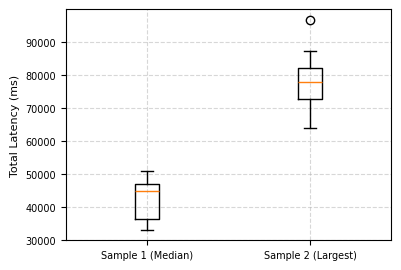

In [11]:
def plot_two_boxplots(df_median, df_max):
    plt.figure(figsize=(4.2,3))

    plt.boxplot(
        [df_median["total"], df_max["total"]],
        tick_labels=["Sample 1 (Median)", "Sample 2 (Largest)"]
    )

    plt.ylabel("Total Latency (ms)")

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
plot_two_boxplots(metric_median, metric_maximum)

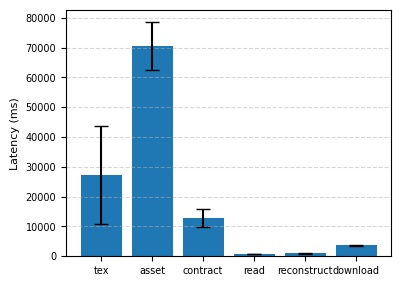

In [12]:
def plot_stage_variance(df):
    metrics = ["tex", "asset", "contract", "read", "reconstruct", "download"]

    means = [df[m].mean() for m in metrics]
    stds = [df[m].std() for m in metrics]

    plt.figure(figsize=(4.2,3.2))
    plt.bar(metrics, means, yerr=stds, capsize=5)

    plt.ylabel("Latency (ms)")
    # plt.title("Latency Breakdown with Variance")

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()
plot_stage_variance(metric_maximum)

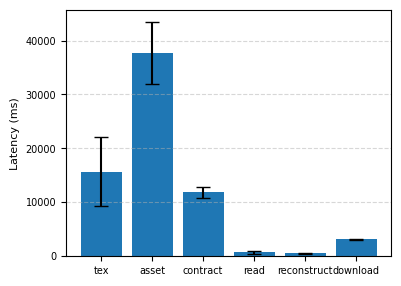

In [13]:
plot_stage_variance(metric_median)

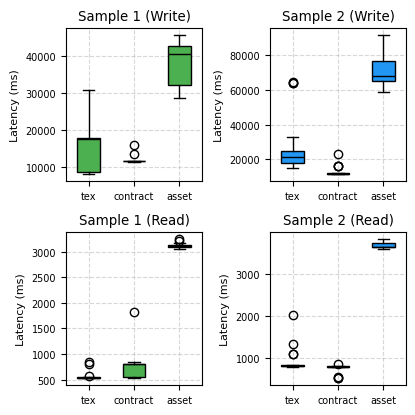

In [14]:
def plot_variance_separate(df_s1, df_s2):

    write_stages = ["tex", "contract", "asset"]
    read_stages = ["reconstruct", "read", "download"]

    def draw_subplot(ax, df, stages, title, color):
        data = [df[s].values for s in stages]

        ax.boxplot(
            data,
            patch_artist=True,
            widths=0.5,
            boxprops=dict(facecolor=color, edgecolor="black"),
            medianprops=dict(color="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black")
        )

        ax.set_xticks(range(1, len(stages)+1))
        ax.set_xticklabels(write_stages)
        ax.set_ylabel("Latency (ms)")
        ax.set_title(title)

        ax.grid(True, linestyle="--", alpha=0.5)

    fig, axes = plt.subplots(2, 2, figsize=(4.2, 4.2))

    draw_subplot(axes[0,0], df_s1, write_stages, "Sample 1 (Write)", "#4CAF50")
    draw_subplot(axes[0,1], df_s2, write_stages, "Sample 2 (Write)", "#2196F3")

    draw_subplot(axes[1,0], df_s1, read_stages, "Sample 1 (Read)", "#4CAF50")
    draw_subplot(axes[1,1], df_s2, read_stages, "Sample 2 (Read)", "#2196F3")

    plt.tight_layout()
    plt.show()
plot_variance_separate(metric_median, metric_maximum)

In [143]:
def get_asset_cost(df, run):
    df = df[df["run"] == run]
    asset = df[df["stage"] == "asset_upload"]["wei"].sum()
    contract = df[df["stage"] == "submit"]["gas"].sum()
    tex = df[df["stage"] == "tex_upload"]["gas"].sum()
    cost = np.array([gas_to_usd(contract), gas_to_usd(tex), wei_to_usd(asset)])
    
    return cost, cost.sum()
get_asset_cost(median, 1010)

(array([0.45374897, 0.79651132, 2.72956484]), np.float64(3.9798251326781235))

In [144]:
get_asset_cost(maximum, 1010)

(array([0.58445085, 7.54233141, 5.72188658]), np.float64(13.84866884055776))

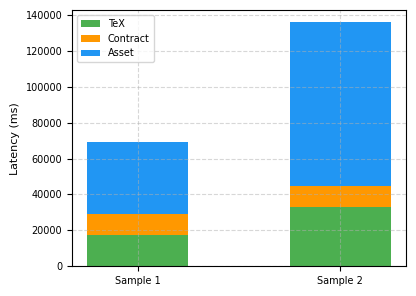

In [19]:
def plot_stacked_latency(df_s1, df_s2):
    # =========================
    # 📊 取代表值（和你论文一致）
    # =========================
    # Sample 1 → median run
    s1 = df_s1.iloc[(df_s1["total"] - df_s1["total"].median()).abs().argmin()]

    # Sample 2 → max run
    s2 = df_s2.loc[df_s2["total"].idxmax()]

    # =========================
    # 📦 构造数据
    # =========================
    labels = ["Sample 1", "Sample 2"]

    tex = [s1["tex"], s2["tex"]]
    contract = [s1["contract"], s2["contract"]]
    asset = [s1["asset"], s2["asset"]]

    x = np.arange(len(labels))

    width = 0.5

    # =========================
    # 🎨 画图
    # =========================
    plt.figure(figsize=(4.2, 3))

    # stack
    plt.bar(x, tex, width, label="TeX", color="#4CAF50")
    plt.bar(x, contract, width, bottom=tex, label="Contract", color="#FF9800")
    plt.bar(x, asset, width, bottom=np.array(tex) + np.array(contract), label="Asset", color="#2196F3")

    # =========================
    # 🧾 细节
    # =========================
    plt.xticks(x, labels)
    plt.ylabel("Latency (ms)")

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()
plot_stacked_latency(metric_median, metric_maximum)

## sample 1 select median

In [81]:
def select_median_run(df):
    median_val = df["total"].median()
    df["diff"] = abs(df["total"] - median_val)
    return int(df.loc[df["diff"].idxmin()]["run"])
select_median_run(metric_median)

1016

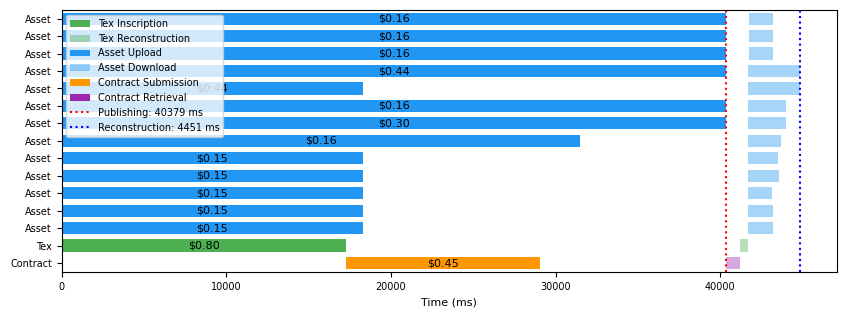

In [122]:
draw_pipeline_csv(median, 1016)

In [191]:
print(generate_pipeline_table_latex(median, 1016))

\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}crrrrr}
    \toprule
    & \multirow{2}{*}{\textbf{Size}(bytes)} &\multicolumn{2}{c}{\textbf{Cost}} & \multicolumn{2}{c}{\textbf{Time} (ms)} \\
    &  &chunks & USD & submit & read \\
    \midrule
    \textbf{contract} & 708 && 0.45 & 11,786 & 804 \\
    \midrule
    \textbf{tex} & 17,039 && 0.80 & 17,287 & 533 \\
    \midrule
    \multirow{13}{*}{\textbf{asset}} & 213 & 1 & 0.15 & 18,300 & 1,471 \\
    & 9,117 & 1 & 0.15 & 18,299 & 1,483 \\
    & 1,343 & 1 & 0.15 & 18,299 & 1,456 \\
    & 318,864 & 3 & 0.44 & 18,298 & 3,106 \\
    & 38,563 & 1 & 0.15 & 18,298 & 1,845 \\
    & 38,299 & 1 & 0.15 & 18,297 & 1,816 \\
    & 65,475 & 1 & 0.16 & 31,483 & 1,969 \\
    & 122,958 & 1 & 0.16 & 40,375 & 2,252 \\
    & 138,802 & 2 & 0.30 & 40,375 & 2,252 \\
    & 316,278 & 3 & 0.44 & 40,374 & 3,110 \\
    & 42,312 & 1 & 0.16 & 40,374 & 1,466 \\
    & 20,137 & 1 & 0.16 & 40,373 & 1,466 \\
    & 32,146 & 1 & 0.16 & 40,373 & 1,478 \\
    \bottomrul

## sample 2 select max

In [86]:
def select_median_run(df):
    return int(df.loc[df["total"].idxmax()]["run"])
select_median_run(metric_maximum)

1028

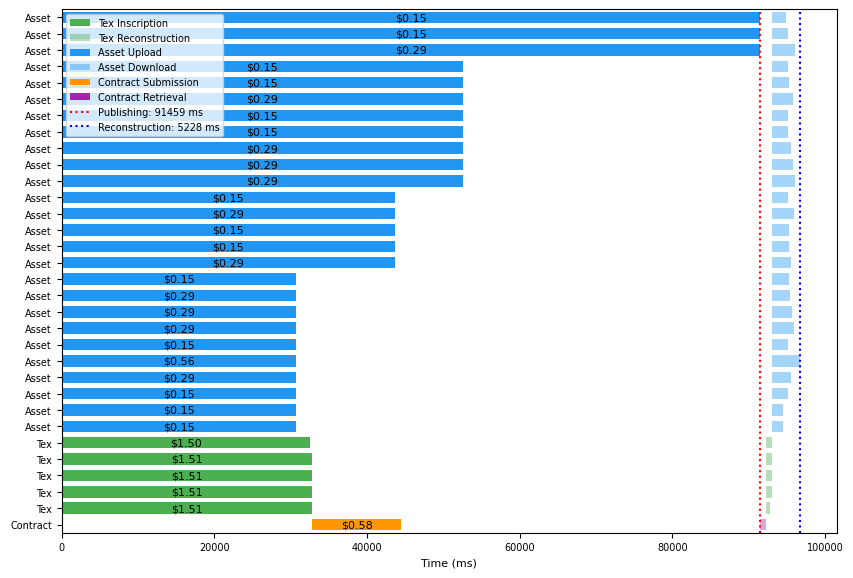

In [123]:
draw_pipeline_csv(maximum, 1028)

In [189]:
print(generate_pipeline_table_latex(maximum, 1028))

\begin{tabular*}{\columnwidth}{@{\extracolsep{\fill}}crrrrr}
    \toprule
    & \multirow{2}{*}{\textbf{Size}(bytes)} &\multicolumn{2}{c}{\textbf{Cost}} & \multicolumn{2}{c}{\textbf{Time} (ms)} \\
    &  &chunks & USD & submit & read \\
    \midrule
    \textbf{contract} & 804 && 0.58 & 11,665 & 806 \\
    \midrule
    \textbf{tex} & 163,727 && 7.54 & 32,803 & 804 \\
    \midrule
    \multirow{26}{*}{\textbf{asset}} & 213 & 1 & 0.15 & 30,723 & 1,460 \\
    & 7,642 & 1 & 0.15 & 30,722 & 1,489 \\
    & 78,613 & 1 & 0.15 & 30,722 & 2,035 \\
    & 160,863 & 2 & 0.29 & 30,721 & 2,503 \\
    & 421,484 & 4 & 0.56 & 30,721 & 3,614 \\
    & 66,165 & 1 & 0.15 & 30,720 & 2,089 \\
    & 208,111 & 2 & 0.29 & 30,720 & 2,881 \\
    & 222,505 & 2 & 0.29 & 30,720 & 2,629 \\
    & 147,093 & 2 & 0.29 & 30,719 & 2,312 \\
    & 99,968 & 1 & 0.15 & 30,719 & 2,230 \\
    & 170,078 & 2 & 0.29 & 43,691 & 2,463 \\
    & 110,914 & 1 & 0.15 & 43,690 & 2,207 \\
    & 116,937 & 1 & 0.15 & 43,690 & 2,262 \\
    & 23

In [112]:
gas_to_usd(size_to_gas(17039))

0.79707175624575